# ODE Solvers: From Euler to Runge–Kutta

## Explicit Euler, Implicit Euler, Trapezoidal Rule & Classical RK4

This notebook implements and compares four fundamental methods for
solving the initial value problem

$$
\frac{dy}{dx} = f(x,\,y), \qquad y(x_0) = y_0
$$

| Method | Formula | Order | Implicit? |
|--------|---------|:-----:|:---------:|
| Explicit Euler | $y_{n+1} = y_n + h\,f(x_n, y_n)$ | 1 | No |
| Implicit Euler | $y_{n+1} = y_n + h\,f(x_{n+1}, y_{n+1})$ | 1 | Yes |
| Trapezoidal | $y_{n+1} = y_n + \tfrac{h}{2}\bigl[f(x_n,y_n) + f(x_{n+1},y_{n+1})\bigr]$ | 2 | Yes |
| Classical RK4 | $y_{n+1} = y_n + \tfrac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$ | 4 | No |

The **Trapezoidal Rule** is the *average of explicit and implicit Euler*
and gains a full order of accuracy for free.

---

## 1 — Imports

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


## 2 — The Four Methods

### 2.1 Explicit (Forward) Euler

The simplest possible method: take one step in the direction
of the current slope.

$$y_{n+1} = y_n + h\,f(x_n, y_n)$$

### 2.2 Implicit (Backward) Euler

Use the slope at the **next** (unknown) point. This requires
solving a nonlinear equation at each step, but gains
**unconditional stability** — crucial for stiff problems.

$$y_{n+1} = y_n + h\,f(x_{n+1}, y_{n+1})$$

### 2.3 Trapezoidal Rule (Crank–Nicolson)

Average the slopes at both ends. Equivalently, this is the
*average of the explicit and implicit Euler formulas*:

$$
y_{n+1} = y_n + \frac{h}{2}\bigl[f(x_n, y_n) + f(x_{n+1}, y_{n+1})\bigr]
$$

It is also implicit, but achieves **2nd-order** accuracy while
retaining good stability (A-stable).

### 2.4 Classical RK4

Four slope evaluations per step, combined with specific weights:

$$
k_1 = f(x_n,\, y_n)
\qquad
k_2 = f\!\left(x_n + \tfrac{h}{2},\, y_n + \tfrac{h}{2}k_1\right)
$$
$$
k_3 = f\!\left(x_n + \tfrac{h}{2},\, y_n + \tfrac{h}{2}k_2\right)
\qquad
k_4 = f(x_n + h,\, y_n + h\,k_3)
$$
$$
y_{n+1} = y_n + \frac{h}{6}\bigl(k_1 + 2k_2 + 2k_3 + k_4\bigr)
$$

In [22]:
def explicit_euler(f, x0, y0, x_end, h):
    """Forward Euler: y_{n+1} = y_n + h * f(x_n, y_n)."""
    xs, ys = [x0], [y0]
    x, y = x0, y0
    while x < x_end - 1e-12:
        y = y + h * f(x, y)
        x = x + h
        xs.append(x); ys.append(y)
    return np.array(xs), np.array(ys)


def _newton_solve(g, dg, y_guess, tol=1e-12, max_iter=50):
    """
    Solve g(y) = 0 using Newton's method.
    dg is the derivative dg/dy.
    """
    y = y_guess
    for _ in range(max_iter):
        dy = -g(y) / dg(y)
        y += dy
        if abs(dy) < tol:
            break
    return y


def implicit_euler(f, x0, y0, x_end, h):
    """
    Backward Euler: y_{n+1} = y_n + h * f(x_{n+1}, y_{n+1}).

    The implicit equation  g(z) = z - y_n - h*f(x_{n+1}, z) = 0
    is solved with Newton's method at each step.
    """
    xs, ys = [x0], [y0]
    x, y = x0, y0
    eps = 1e-8   # for numerical derivative

    while x < x_end - 1e-12:
        xn = x + h
        yn = y                         # freeze current values

        def g(z, _xn=xn, _yn=yn):     # bind by default arg
            return z - _yn - h * f(_xn, z)

        def dg(z, _xn=xn):
            return 1.0 - h * (f(_xn, z + eps) - f(_xn, z - eps)) / (2 * eps)

        y_guess = yn + h * f(x, yn)    # explicit Euler as seed
        y = _newton_solve(g, dg, y_guess)
        x = xn
        xs.append(x); ys.append(y)

    return np.array(xs), np.array(ys)


def trapezoidal(f, x0, y0, x_end, h):
    """
    Trapezoidal rule (Crank-Nicolson):
    y_{n+1} = y_n + h/2 * [f(x_n, y_n) + f(x_{n+1}, y_{n+1})].
    """
    xs, ys = [x0], [y0]
    x, y = x0, y0
    eps = 1e-8

    while x < x_end - 1e-12:
        xn  = x + h
        yn  = y
        f_n = f(x, yn)                 # slope at current point

        def g(z, _xn=xn, _yn=yn, _fn=f_n):
            return z - _yn - (h / 2) * (_fn + f(_xn, z))

        def dg(z, _xn=xn):
            return 1.0 - (h / 2) * (f(_xn, z + eps) - f(_xn, z - eps)) / (2 * eps)

        y_guess = yn + h * f_n
        y = _newton_solve(g, dg, y_guess)
        x = xn
        xs.append(x); ys.append(y)

    return np.array(xs), np.array(ys)


def rk4(f, x0, y0, x_end, h):
    """Classical 4th-order Runge-Kutta."""
    xs, ys = [x0], [y0]
    x, y = x0, y0
    while x < x_end - 1e-12:
        k1 = f(x, y)
        k2 = f(x + h/2, y + h/2 * k1)
        k3 = f(x + h/2, y + h/2 * k2)
        k4 = f(x + h,   y + h   * k3)
        y = y + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)
        x = x + h
        xs.append(x); ys.append(y)
    return np.array(xs), np.array(ys)


## 3 — Reference Solution

We use `scipy.integrate.solve_ivp` (RK45 with tight tolerances)
as a high-accuracy reference to measure the error of each method.

In [23]:
def reference_solution(f, x0, y0, x_end, n_pts=1000):
    """High-accuracy reference via adaptive RK45."""
    sol = solve_ivp(
        lambda x, y: [f(x, y[0])],
        (x0, x_end), [y0],
        method="RK45",
        t_eval=np.linspace(x0, x_end, n_pts),
        rtol=1e-12, atol=1e-14,
    )
    return sol.t, sol.y[0]

## 4 — Test Problem & Visual Comparison

$$
\frac{dy}{dx} = -y + \sin(x) + 1, \qquad y(0) = 1
$$

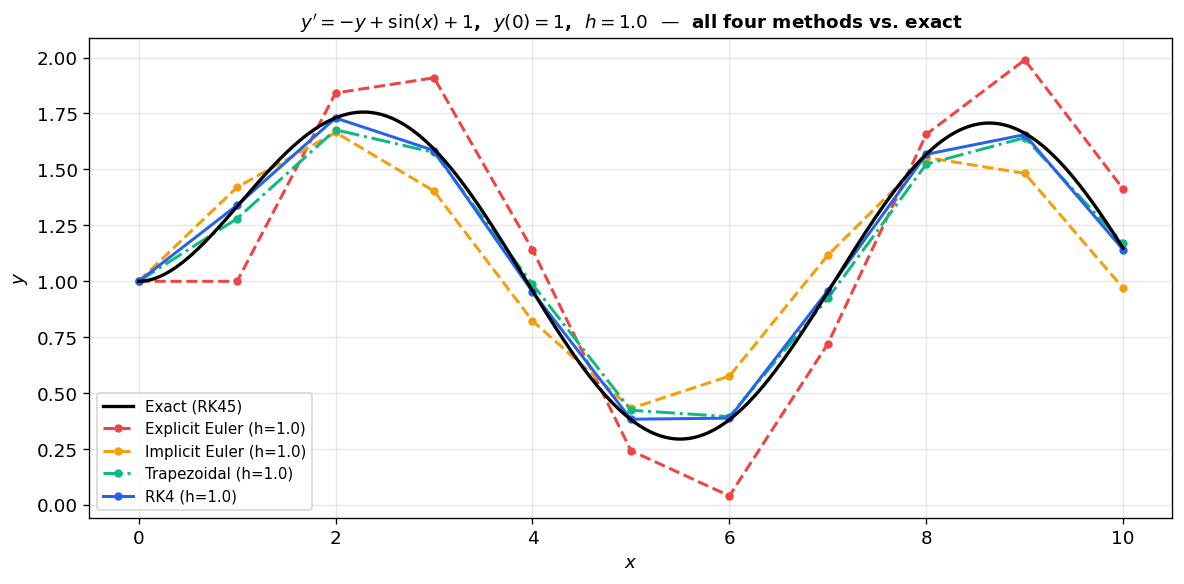

In [24]:
f = lambda x, y: -y + np.sin(x) + 1
x0, y0 = 0.0, 1.0
x_end  = 10.0
h      = 1.0       # deliberately coarse to show differences

methods = [
    ("Explicit Euler",  explicit_euler, "#ef4444", "--"),
    ("Implicit Euler",  implicit_euler, "#f59e0b", "--"),
    ("Trapezoidal",     trapezoidal,    "#10b981", "-."),
    ("RK4",             rk4,            "#2563eb", "-"),
]

# Reference
x_ref, y_ref = reference_solution(f, x0, y0, x_end)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_ref, y_ref, "k-", lw=2, label="Exact (RK45)", zorder=5)

for name, solver, col, ls in methods:
    xs, ys = solver(f, x0, y0, x_end, h)
    ax.plot(xs, ys, ls, color=col, lw=1.8, marker="o", markersize=4,
            label=f"{name} (h={h})")

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.legend(fontsize=9)
ax.set_title(
    r"$y' = -y + \sin(x) + 1$,  $y(0)=1$,  $h = 1.0$"
    "  —  all four methods vs. exact",
    fontsize=11, fontweight="bold",
)
fig.tight_layout()
plt.show()

With such a coarse step ($h=1$), the two Euler methods visibly
oscillate around the true solution — explicit overshoots and
implicit undershoots. The trapezoidal rule (their average) is
already much closer. RK4 is nearly indistinguishable from exact.

## 5 — Trapezoidal = Average of Euler *Formulas*

Write down the two Euler formulas side by side:

$$
\text{Explicit:} \quad y_{n+1} = y_n + h\,f(x_n,\, y_n)
$$
$$
\text{Implicit:} \quad y_{n+1} = y_n + h\,f(x_{n+1},\, y_{n+1})
$$

Now average the **right-hand sides**:

$$
y_{n+1} = y_n + \frac{h}{2}\bigl[f(x_n,\, y_n) + f(x_{n+1},\, y_{n+1})\bigr]
$$

That *is* the trapezoidal rule. The key insight is that the explicit
Euler uses the slope at the *start*, the implicit Euler at the *end*,
and the trapezoidal rule uses *both* — gaining one order of accuracy.

Let's show that the trapezoidal result always sits between the
two Euler solutions:

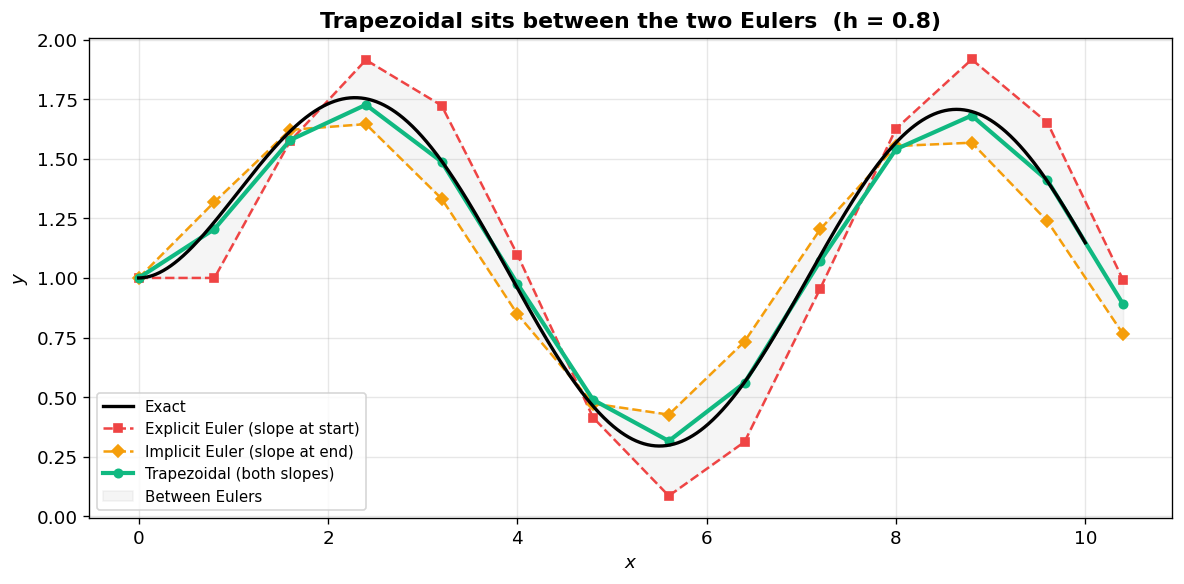

In [25]:
f = lambda x, y: -y + np.sin(x) + 1
x0, y0, x_end = 0.0, 1.0, 10.0
h = 0.8

xs_ee, ys_ee = explicit_euler(f, x0, y0, x_end, h)
xs_ie, ys_ie = implicit_euler(f, x0, y0, x_end, h)
xs_tr, ys_tr = trapezoidal(f, x0, y0, x_end, h)
x_ref, y_ref = reference_solution(f, x0, y0, x_end)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_ref, y_ref, "k-", lw=2, label="Exact", zorder=5)
ax.plot(xs_ee, ys_ee, "--", color="#ef4444", lw=1.5, marker="s",
        markersize=5, label="Explicit Euler (slope at start)")
ax.plot(xs_ie, ys_ie, "--", color="#f59e0b", lw=1.5, marker="D",
        markersize=5, label="Implicit Euler (slope at end)")
ax.plot(xs_tr, ys_tr, "-", color="#10b981", lw=2.5,
        marker="o", markersize=5, label="Trapezoidal (both slopes)")

# Shade between Euler curves
n = min(len(xs_ee), len(xs_ie))
ax.fill_between(xs_ee[:n], ys_ee[:n], ys_ie[:n],
                alpha=0.08, color="grey", label="Between Eulers")

ax.legend(fontsize=9)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(
    f"Trapezoidal sits between the two Eulers  (h = {h})",
    fontweight="bold",
)
fig.tight_layout()
plt.show()


## 6 — Convergence Study

The error should decrease as $h \to 0$. The **rate** reveals
each method's order of accuracy.

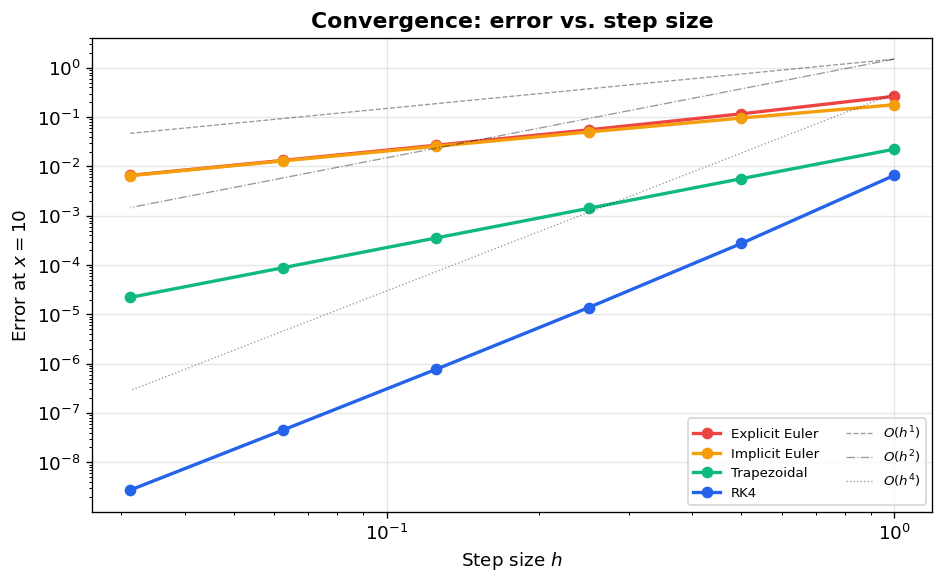

In [26]:
# Evaluate the reference at the end point
_, y_exact_end = reference_solution(f, x0, y0, x_end, n_pts=2)
y_exact = y_exact_end[-1]

H_values = np.array([1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125])

fig, ax = plt.subplots(figsize=(8, 5))

for name, solver, col, _ in methods:
    errors = []
    for h in H_values:
        xs, ys = solver(f, x0, y0, x_end, h)
        errors.append(abs(ys[-1] - y_exact))
    ax.loglog(H_values, errors, "o-", color=col, lw=2, markersize=6,
              label=name)

# Reference slopes
ax.loglog(H_values, 1.5 * H_values,       "k--", lw=0.8, alpha=0.4,
          label="$O(h^1)$")
ax.loglog(H_values, 1.5 * H_values**2,    "k-.", lw=0.8, alpha=0.4,
          label="$O(h^2)$")
ax.loglog(H_values, 0.3 * H_values**4,    "k:",  lw=0.8, alpha=0.4,
          label="$O(h^4)$")

ax.set_xlabel("Step size $h$")
ax.set_ylabel("Error at $x = 10$")
ax.set_title("Convergence: error vs. step size", fontweight="bold")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

In [27]:
# Print convergence ratios
print(f"{'Method':<20} {'h':>8} {'Error':>12} {'Ratio':>8}")
print("=" * 52)

for name, solver, _, _ in methods:
    prev_err = None
    print(f"\n{name}")
    print("-" * 52)
    for h in H_values:
        xs, ys = solver(f, x0, y0, x_end, h)
        err = abs(ys[-1] - y_exact)
        ratio = f"{prev_err / err:.1f}" if prev_err else "—"
        print(f"{'':20} {h:>8.4f} {err:>12.2e} {ratio:>8}")
        prev_err = err

Method                      h        Error    Ratio

Explicit Euler
----------------------------------------------------
                       1.0000     2.65e-01        —
                       0.5000     1.17e-01      2.3
                       0.2500     5.52e-02      2.1
                       0.1250     2.69e-02      2.1
                       0.0625     1.33e-02      2.0
                       0.0312     6.59e-03      2.0

Implicit Euler
----------------------------------------------------
                       1.0000     1.78e-01        —
                       0.5000     9.59e-02      1.9
                       0.2500     5.00e-02      1.9
                       0.1250     2.56e-02      2.0
                       0.0625     1.29e-02      2.0
                       0.0312     6.51e-03      2.0

Trapezoidal
----------------------------------------------------
                       1.0000     2.24e-02        —
                       0.5000     5.65e-03      4.0
                

**Expected convergence ratios** when $h$ is halved:

| Method | Order | Ratio |
|--------|:-----:|:-----:|
| Explicit / Implicit Euler | 1 | ~2 |
| Trapezoidal | 2 | ~4 |
| RK4 | 4 | ~16 |

## 7 — Stability: Why Implicit Methods Matter

Consider the **stiff** test problem

$$\frac{dy}{dx} = -50\,(y - \cos(x)), \qquad y(0) = 1$$

The large coefficient $\lambda = -50$ means the exact solution decays
very fast toward $\cos(x)$. Explicit methods need *tiny* steps
($h < 2/|\lambda| = 0.04$) or they **blow up**. Implicit methods
remain stable with much larger steps.

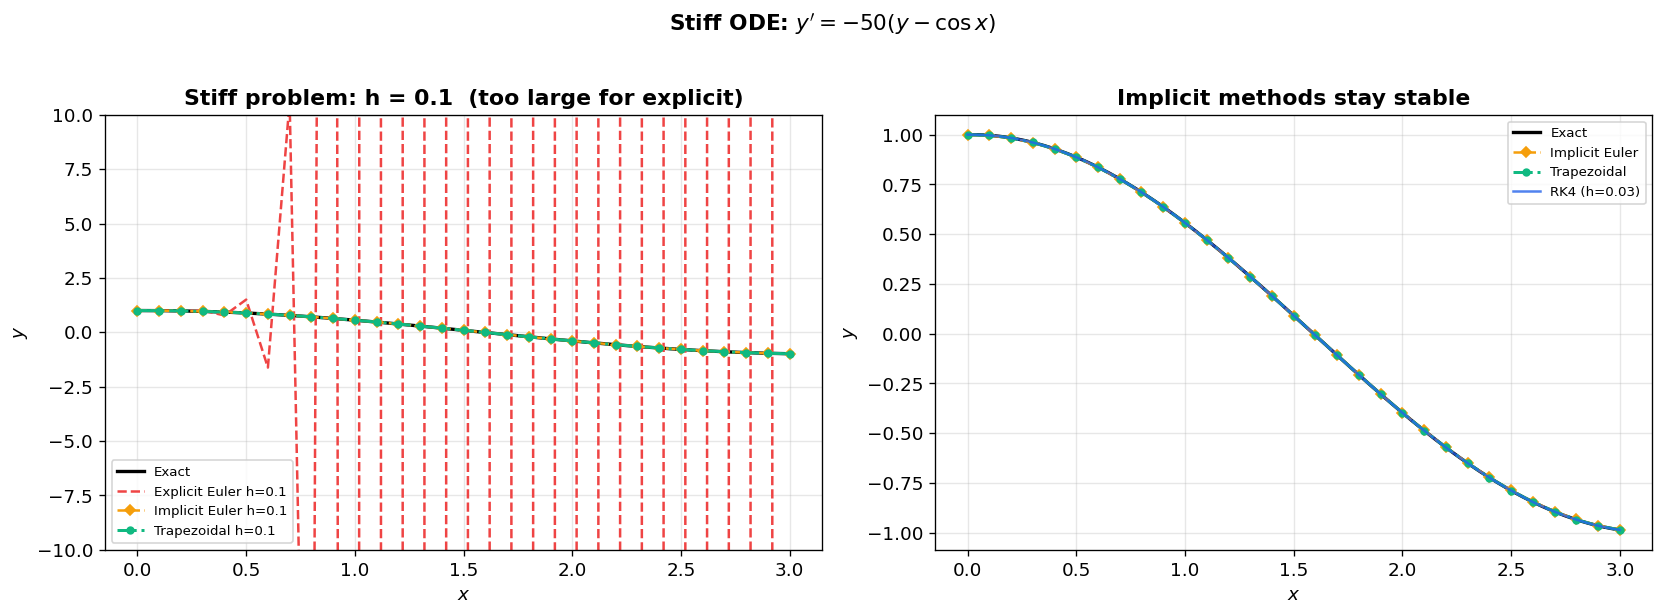

In [28]:
f_stiff = lambda x, y: -50 * (y - np.cos(x))
x0, y0 = 0.0, 1.0
x_end  = 3.0
h      = 0.1       # too large for explicit on this stiff problem!

x_ref_s, y_ref_s = reference_solution(f_stiff, x0, y0, x_end)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full view (explicit Euler blows up)
ax = axes[0]
ax.plot(x_ref_s, y_ref_s, "k-", lw=2, label="Exact")

try:
    xs_ee, ys_ee = explicit_euler(f_stiff, x0, y0, x_end, h)
    ax.plot(xs_ee, ys_ee, "--", color="#ef4444", lw=1.5,
            label=f"Explicit Euler h={h}")
except:
    pass

xs_ie, ys_ie = implicit_euler(f_stiff, x0, y0, x_end, h)
xs_tr, ys_tr = trapezoidal(f_stiff, x0, y0, x_end, h)

ax.plot(xs_ie, ys_ie, "--", color="#f59e0b", lw=1.5, marker="D",
        markersize=4, label=f"Implicit Euler h={h}")
ax.plot(xs_tr, ys_tr, "-.", color="#10b981", lw=1.8, marker="o",
        markersize=4, label=f"Trapezoidal h={h}")

ax.set_ylim(-10, 10)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.legend(fontsize=8)
ax.set_title(f"Stiff problem: h = {h}  (too large for explicit)",
             fontweight="bold")

# Right: zoomed-in implicit methods vs exact
ax = axes[1]
ax.plot(x_ref_s, y_ref_s, "k-", lw=2, label="Exact")
ax.plot(xs_ie, ys_ie, "--", color="#f59e0b", lw=1.5, marker="D",
        markersize=4, label=f"Implicit Euler")
ax.plot(xs_tr, ys_tr, "-.", color="#10b981", lw=1.8, marker="o",
        markersize=4, label=f"Trapezoidal")

# RK4 with safe step size
xs_rk, ys_rk = rk4(f_stiff, x0, y0, x_end, h=0.03)
ax.plot(xs_rk, ys_rk, "-", color="#2563eb", lw=1.5, alpha=0.8,
        label="RK4 (h=0.03)")

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.legend(fontsize=8)
ax.set_title("Implicit methods stay stable", fontweight="bold")

fig.suptitle(
    r"Stiff ODE: $y' = -50(y - \cos x)$",
    fontsize=13, fontweight="bold", y=1.02,
)
fig.tight_layout()
plt.show()

## 8 — The RK4 Construction: Visualising the Four Slopes

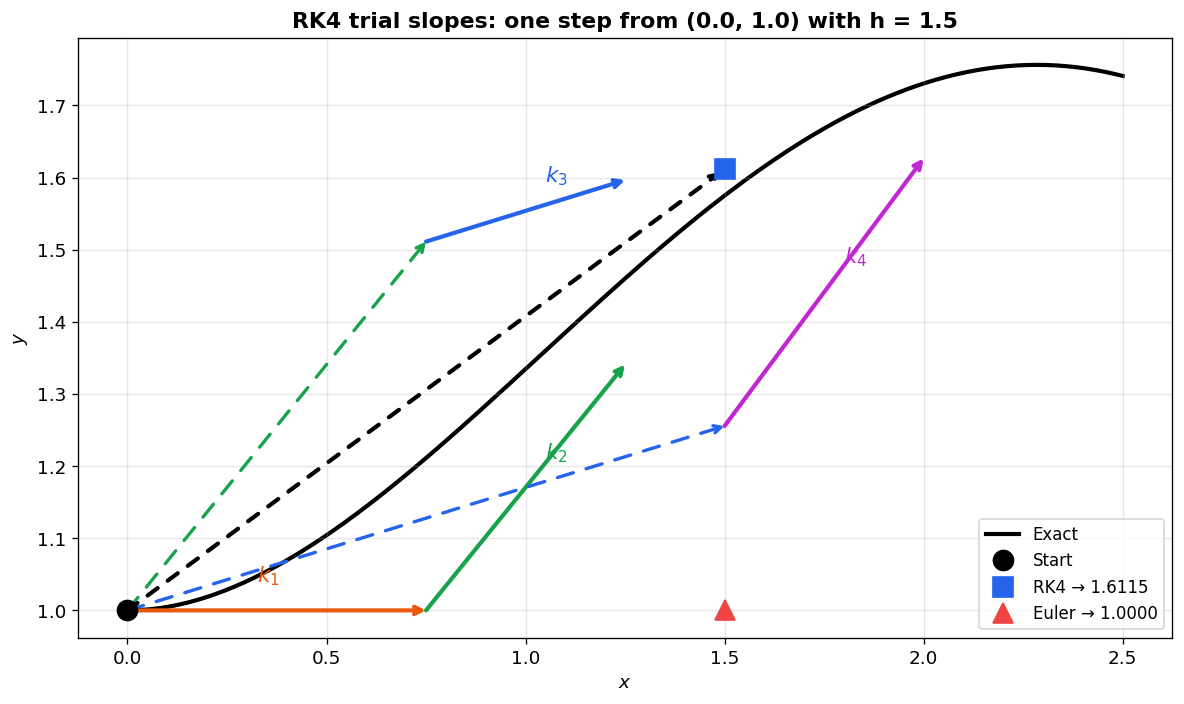

  k1 = 0.0000   (slope at start)
  k2 = 0.6816   (slope at midpoint via k1)
  k3 = 0.1704   (slope at midpoint via k2)
  k4 = 0.7419   (slope at end via k3)
  Weighted average = (k1 + 2k2 + 2k3 + k4)/6 = 0.4077


In [29]:
f = lambda x, y: -y + np.sin(x) + 1
x0, y0, h = 0.0, 1.0, 1.5

# Compute the four slopes
k1 = f(x0, y0)
k2 = f(x0 + h/2, y0 + h/2 * k1)
k3 = f(x0 + h/2, y0 + h/2 * k2)
k4 = f(x0 + h,   y0 + h   * k3)
y_rk4  = y0 + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
y_euler = y0 + h * k1

fig, ax = plt.subplots(figsize=(10, 6))

# Background: exact curve
x_ref, y_ref = reference_solution(f, x0, y0, x0 + h + 1, 300)
ax.plot(x_ref, y_ref, "k-", lw=2.5, label="Exact", zorder=1)

arrow_kw = dict(arrowstyle="->", lw=2.5, shrinkA=0, shrinkB=0)
dot_kw   = dict(arrowstyle="->", lw=2.0, shrinkA=0, shrinkB=0,
                linestyle=(0, (5, 4)))   # dashed

# --- k1: solid orange, slope at start, half-step long ---
ax.annotate("", xy=(x0 + h/2, y0 + (h/2)*k1), xytext=(x0, y0),
    arrowprops=dict(**arrow_kw, color="#ea580c"))
ax.text(x0 + h/4 - 0.05, y0 + (h/4)*k1 + 0.04, "$k_1$",
        color="#ea580c", fontsize=13, fontweight="bold")

# --- k2: solid green arrow at its evaluation point ---
P1x, P1y = x0 + h/2, y0 + (h/2)*k1
ax.annotate("", xy=(P1x + h/3, P1y + (h/3)*k2), xytext=(P1x, P1y),
    arrowprops=dict(**arrow_kw, color="#16a34a"))
ax.text(P1x + h/6 + 0.05, P1y + (h/6)*k2 + 0.04, "$k_2$",
        color="#16a34a", fontsize=13, fontweight="bold")

# --- k2 DOTTED: from start with slope k2, reaching midpoint ---
ax.annotate("", xy=(x0 + h/2, y0 + (h/2)*k2), xytext=(x0, y0),
    arrowprops=dict(**dot_kw, color="#16a34a"))

# --- k3: solid blue arrow at its evaluation point ---
P2x, P2y = x0 + h/2, y0 + (h/2)*k2
ax.annotate("", xy=(P2x + h/3, P2y + (h/3)*k3), xytext=(P2x, P2y),
    arrowprops=dict(**arrow_kw, color="#2563eb"))
ax.text(P2x + h/6 + 0.05, P2y + (h/6)*k3 + 0.04, "$k_3$",
        color="#2563eb", fontsize=13, fontweight="bold")

# --- k3 DOTTED: from start with slope k3, reaching full step ---
ax.annotate("", xy=(x0 + h, y0 + h*k3), xytext=(x0, y0),
    arrowprops=dict(**dot_kw, color="#2563eb"))

# --- k4: solid magenta arrow at its evaluation point ---
P3x, P3y = x0 + h, y0 + h*k3
ax.annotate("", xy=(P3x + h/3, P3y + (h/3)*k4), xytext=(P3x, P3y),
    arrowprops=dict(**arrow_kw, color="#c026d3"))
ax.text(P3x + h/6 + 0.05, P3y + (h/6)*k4 + 0.04, "$k_4$",
        color="#c026d3", fontsize=13, fontweight="bold")

# --- ACTUAL RK4 STEP: black dashed arrow from start to result ---
ax.annotate("",
    xy=(x0 + h, y_rk4), xytext=(x0, y0),
    arrowprops=dict(arrowstyle="->", color="black", lw=2.5,
                    linestyle=(0, (3, 3)), shrinkA=0, shrinkB=3),
    zorder=6)

# Start and end points
ax.plot(x0, y0, "ko", markersize=12, zorder=7, label="Start")
ax.plot(x0 + h, y_rk4, "s", color="#2563eb", markersize=12,
        zorder=7, label=f"RK4 → {y_rk4:.4f}")
ax.plot(x0 + h, y_euler, "^", color="#ef4444", markersize=12,
        zorder=7, label=f"Euler → {y_euler:.4f}")

ax.legend(fontsize=10, loc="lower right")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(
    f"RK4 trial slopes: one step from ({x0}, {y0}) with h = {h}",
    fontweight="bold",
)
fig.tight_layout()
plt.show()

print(f"  k1 = {k1:.4f}   (slope at start)")
print(f"  k2 = {k2:.4f}   (slope at midpoint via k1)")
print(f"  k3 = {k3:.4f}   (slope at midpoint via k2)")
print(f"  k4 = {k4:.4f}   (slope at end via k3)")
print(f"  Weighted average = (k1 + 2k2 + 2k3 + k4)/6 = "
      f"{(k1 + 2*k2 + 2*k3 + k4)/6:.4f}")


## 9 — Summary Table: Accuracy vs. Cost

In [ ]:
f = lambda x, y: -y + np.sin(x) + 1
x0, y0, x_end = 0.0, 1.0, 10.0
_, y_ref_end = reference_solution(f, x0, y0, x_end, 2)
y_exact = y_ref_end[-1]

print(f"{'Method':<20} {'Order':>5} {'h=0.5 error':>14} "
      f"{'h=0.1 error':>14} {'f-evals/step':>14}")
print("=" * 72)

info = [
    ("Explicit Euler",  explicit_euler, 1, 1),
    ("Implicit Euler",  implicit_euler, 1, "~3–5"),
    ("Trapezoidal",     trapezoidal,    2, "~3–5"),
    ("RK4",             rk4,            4, 4),
]

for name, solver, order, cost in info:
    e1 = abs(solver(f, x0, y0, x_end, 0.5)[1][-1] - y_exact)
    e2 = abs(solver(f, x0, y0, x_end, 0.1)[1][-1] - y_exact)
    print(f"{name:<20} {order:>5} {e1:>14.2e} {e2:>14.2e} {str(cost):>14}")

## 10 — Notes for Students

### Key take-aways

1. **Explicit Euler** is the simplest method but only 1st-order
   accurate and **conditionally stable** — it can blow up on stiff
   problems if $h$ is too large.

2. **Implicit Euler** is also 1st-order but **unconditionally stable**
   (A-stable). The price is solving a nonlinear equation at every step.

3. **Trapezoidal Rule** is literally the average of explicit and
   implicit Euler, yet it jumps to **2nd-order** accuracy. It is
   also A-stable — the best of both worlds.

4. **RK4** is the workhorse of non-stiff ODE solving: **4th-order**
   accuracy with only 4 function evaluations per step. However,
   it is explicit and therefore not suitable for stiff problems.

5. **Stiffness** is the key criterion for choosing a method.
   Non-stiff → RK4 (or RK45). Stiff → implicit methods
   (trapezoidal, BDF, ESDIRK, …).

### Exercises

1. For the stiff problem $y' = -50(y - \cos x)$, find the largest
   step size $h$ for which explicit Euler remains stable. Compare
   with the theoretical limit $h < 2/|\lambda|$.

2. Implement the **implicit midpoint rule**:
   $y_{n+1} = y_n + h\,f\bigl(x_n + h/2,\; (y_n + y_{n+1})/2\bigr)$.
   What order of accuracy does it achieve?

3. Verify numerically that the trapezoidal method gives the
   **exact** answer for any linear ODE $y' = ay + b$ regardless
   of step size (it integrates linears exactly).

4. Add a 5th method to the convergence plot: the **2nd-order
   Heun method** (explicit trapezoidal / improved Euler):
   $\tilde{y} = y_n + h f(x_n, y_n)$,
   $y_{n+1} = y_n + \frac{h}{2}[f(x_n, y_n) + f(x_{n+1}, \tilde{y})]$.
   Confirm it is 2nd-order.

5. Compare `scipy.integrate.solve_ivp` with `method='Radau'`
   (implicit, A-stable, 5th-order) vs. your trapezoidal on the
   stiff problem. Which needs fewer steps for the same accuracy?